# 태양풍 속도 예측 — P3 (Collin 2025 기반 물리 피처)

## 0. 설정

In [1]:
from pathlib import Path
import gc
import json
import math
import os
import random
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 777
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_ROOT_CANDIDATES = [
    Path(os.getenv("SW_DATA_ROOT", "")) if os.getenv("SW_DATA_ROOT") else None,
    Path("public_dataset/competition_dataset_6h"),
    Path("/home/jovyan/public_dataset/competition_dataset_6h"),
    Path("public/public_dataset/competition_dataset_6h"),
    Path("/home/jovyan/public/public_dataset/competition_dataset_6h"),
    Path("dataset"),
    Path("/home/jovyan/dataset"),
]
DATA_ROOT = None
for candidate in DATA_ROOT_CANDIDATES:
    if candidate is not None and (candidate / "train/inputs.csv").exists():
        DATA_ROOT = candidate
        break
if DATA_ROOT is None:
    searched = "\n".join(f"  - {c}" for c in DATA_ROOT_CANDIDATES if c is not None)
    raise FileNotFoundError("데이터 경로를 찾지 못했습니다:\n" + searched)

WORK_DIR = Path("work")
CACHE_ROOT = WORK_DIR / "cache"
OUTPUT_DIR = WORK_DIR / "outputs_p3"
SUBMISSION_DIR = Path("submission")
for directory in (CACHE_ROOT, OUTPUT_DIR, SUBMISSION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 128
CHANNELS = ("193", "211")
BATCH_SIZE = 64
EPOCHS = 60
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-3
GRAD_CLIP = 1.0
SCHEDULER_PATIENCE = 3
EARLY_STOP_PATIENCE = 10
NUM_WORKERS = 4
LOSS_EPSILON = 1e-8
LOSS_SCALE = 100.0
LOSS_MODE = "metric"

# --- 브랜치 스위치 (ablation 용) ---------------------------------------
USE_CNN = False    # 3D CNN 영상 브랜치. P3 기본값은 끔 (과적합 주범)
USE_CH = True      # 코로나홀 격자 피처 브랜치
USE_BALLISTIC = True   # horizon별 탄도 정렬 피처

# --- 코로나홀 추출 (Collin 2025) ---------------------------------------
CH_GRID = (3, 5)          # (위도 구간, 경도 구간). 논문은 4x3 이 timeline RMSE 최적
CH_THRESHOLD_RATIO = 0.45  # 원반 중앙값 대비 이 비율보다 어두우면 코로나홀
DISK_MARGIN = 0.95         # 림 밝아짐(limb brightening) 회피용 반지름 축소
TRANSIT_SPEEDS = (350.0, 500.0, 700.0)   # 탄도 역산에 쓸 가정 속도 (km/s)
AU_KM = 1.496e8

DROPOUT = 0.4
HORIZON_EMBED = 8
AUGMENT = True
AUG_BRIGHTNESS = 0.10
AUG_SHIFT_PIXELS = 6
AUG_NOISE_STD = 0.02
AUG_ERASE_PROB = 0.3
AUG_CH_NOISE = 0.0        # CH 피처에 주는 곱셈 노이즈
CH_DROPOUT = 0.15          # CH 브랜치 전용 dropout

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
PIN_MEMORY = DEVICE.type == "cuda"
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
else:
    print("WARNING: CUDA Unavailable")

print("PyTorch:", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("data:", DATA_ROOT.resolve())
print(f"branches: CNN={USE_CNN} CH={USE_CH} BALLISTIC={USE_BALLISTIC}")

PyTorch: 2.5.1+cu124 | device: cuda
GPU: NVIDIA A100-SXM4-40GB
data: /home/jovyan/public_dataset/competition_dataset_6h
branches: CNN=False CH=True BALLISTIC=True


## 1. 데이터 로드 · 결측 처리

In [2]:
IMAGE_COLUMNS = [f"image_{index:02d}" for index in range(20)]
WIND_COLUMNS = [f"wind_{index:02d}" for index in range(20)]
TARGET_COLUMNS = [f"target_{index:02d}" for index in range(12)]
HORIZONS = np.arange(1, 13) * 6

train_inputs = pd.read_csv(DATA_ROOT / "train/inputs.csv")
train_targets_frame = pd.read_csv(DATA_ROOT / "train/targets.csv")
val_inputs = pd.read_csv(DATA_ROOT / "validation/inputs.csv")
val_targets_frame = pd.read_csv(DATA_ROOT / "validation/targets.csv")
test_inputs = pd.read_csv(DATA_ROOT / "test/inputs.csv")
test_ids = pd.read_csv(DATA_ROOT / "test/test_ids.csv")

assert train_inputs.sample_id.tolist() == train_targets_frame.sample_id.tolist()
assert val_inputs.sample_id.tolist() == val_targets_frame.sample_id.tolist()
assert test_inputs.sample_id.tolist() == test_ids.sample_id.tolist()
assert set(train_inputs.sample_id).isdisjoint(val_inputs.sample_id)
assert set(train_inputs.sample_id).isdisjoint(test_inputs.sample_id)
assert set(val_inputs.sample_id).isdisjoint(test_inputs.sample_id)
assert not any(column.startswith("target_") for column in test_inputs.columns)


def forward_fill_rows(values):
    valid = np.isfinite(values)
    positions = np.where(valid, np.arange(values.shape[1])[None, :], 0)
    np.maximum.accumulate(positions, axis=1, out=positions)
    rows = np.arange(values.shape[0])[:, None]
    return np.where(valid.any(axis=1, keepdims=True), values[rows, positions], values)


def fill_wind(frame, fallback):
    values = frame[WIND_COLUMNS].to_numpy(np.float32)
    valid = np.isfinite(values).astype(np.float32)
    filled = forward_fill_rows(values)
    filled = forward_fill_rows(filled[:, ::-1])[:, ::-1]
    filled = np.where(np.isfinite(filled), filled, fallback)
    return np.ascontiguousarray(filled), np.ascontiguousarray(valid)


WIND_FALLBACK = float(np.nanmedian(train_inputs[WIND_COLUMNS].to_numpy(np.float32)))
train_wind, train_wind_valid = fill_wind(train_inputs, WIND_FALLBACK)
val_wind, val_wind_valid = fill_wind(val_inputs, WIND_FALLBACK)
test_wind, test_wind_valid = fill_wind(test_inputs, WIND_FALLBACK)

train_targets = train_targets_frame[TARGET_COLUMNS].to_numpy(np.float32)
val_targets = val_targets_frame[TARGET_COLUMNS].to_numpy(np.float32)
assert np.isfinite(train_targets).all() and np.isfinite(val_targets).all()

print("samples:", len(train_inputs), len(val_inputs), len(test_inputs))
print(f"train wind mean={train_wind.mean():.1f} target mean={train_targets.mean():.1f}")

samples: 9607 1199 3868
train wind mean=414.6 target mean=415.4


## 2. 이미지 memory-map cache

In [3]:
def prepare_image_memmap(split, inputs):
    image_root = DATA_ROOT / split
    cache_root = CACHE_ROOT / f"{IMAGE_SIZE}px"
    cache_root.mkdir(parents=True, exist_ok=True)
    array_path = cache_root / f"{split}_images.npy"
    metadata_path = cache_root / f"{split}_metadata.json"
    filenames = sorted(pd.unique(inputs[IMAGE_COLUMNS].to_numpy().ravel()).tolist())
    expected = {"image_size": IMAGE_SIZE, "channels": list(CHANNELS), "filenames": filenames}
    shape = (len(filenames), len(CHANNELS), IMAGE_SIZE, IMAGE_SIZE)

    valid = False
    if array_path.exists() and metadata_path.exists():
        try:
            metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
            cached = np.load(array_path, mmap_mode="r")
            valid = (metadata == expected and cached.shape == shape
                     and cached.dtype == np.uint8)
        except (OSError, ValueError, json.JSONDecodeError):
            valid = False

    if not valid:
        array_temp = array_path.with_name(array_path.name + f".partial.{os.getpid()}")
        metadata_temp = metadata_path.with_name(metadata_path.name + f".partial.{os.getpid()}")
        resized = np.lib.format.open_memmap(array_temp, mode="w+", dtype=np.uint8, shape=shape)
        resampling = Image.Resampling.BILINEAR
        for index, filename in enumerate(filenames):
            for channel_index, channel in enumerate(CHANNELS):
                with Image.open(image_root / channel / filename) as image:
                    resized[index, channel_index] = np.asarray(
                        image.convert("L").resize((IMAGE_SIZE, IMAGE_SIZE), resampling),
                        dtype=np.uint8)
            if (index + 1) % 2000 == 0 or index + 1 == len(filenames):
                print(f"{split} resize: {index + 1}/{len(filenames)}", flush=True)
        resized.flush()
        del resized
        metadata_temp.write_text(json.dumps(expected, ensure_ascii=False) + "\n", encoding="utf-8")
        array_temp.replace(array_path)
        metadata_temp.replace(metadata_path)
        print(f"created cache: {array_path.resolve()}")
    else:
        print(f"reusing cache: {array_path.resolve()}")

    image_array = np.load(array_path, mmap_mode="r")
    return image_array, {name: i for i, name in enumerate(filenames)}


train_image_array, train_image_index = prepare_image_memmap("train", train_inputs)
val_image_array, val_image_index = prepare_image_memmap("validation", val_inputs)
test_image_array, test_image_index = prepare_image_memmap("test", test_inputs)
print("고유 이미지:", len(train_image_index), len(val_image_index), len(test_image_index))

reusing cache: /home/jovyan/work/cache/128px/train_images.npy
reusing cache: /home/jovyan/work/cache/128px/validation_images.npy
reusing cache: /home/jovyan/work/cache/128px/test_images.npy
고유 이미지: 10139 1408 4115


## 3. 태양 원반 검출 · 코로나홀 격자 면적 추출 — **P3 핵심**

Collin 2025 의 접근을 규정 내에서 재현합니다.

1. **원반 검출** — train 평균 영상에서 밝은 영역의 중심/반지름을 추정. 림 밝아짐을 피해 반지름을 5% 축소
2. **코로나홀 마스크** — 원반 내부 중앙값 대비 `CH_THRESHOLD_RATIO` 보다 어두우면서
   **193과 211 두 채널 모두에서 어두운** 픽셀만 인정 (논문의 2채널 결합 아이디어)
3. **격자 binning** — 원반을 (위도 × 경도) 격자로 나눠 셀별 CH 면적 비율 산출

결과는 이미지당 `CH_GRID` 개 실수뿐이라 저장 용량이 무시할 수준이고, **저차원이라 과적합에 강합니다.**

원반 검출: center=(63.3, 63.8) radius=59.9px (유효 56.9px, 프레임의 94%)
격자 3x5 = 15 셀, 원반 픽셀 10,167개, 중앙자오선 셀 index=7
reusing CH cache: ch_train_3x5_0.45_128.npy
reusing CH cache: ch_validation_3x5_0.45_128.npy
reusing CH cache: ch_test_3x5_0.45_128.npy

CH 면적 비율 — train 전체 평균 0.0510, 중앙자오선 셀 평균 0.0336


/tmp/ipykernel_16271/2648923879.py:88: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_16271/2648923879.py:88: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_16271/2648923879.py:88: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_16271/2648923879.py:88: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_16271/2648923879.py:88: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_16271/2648923879.py:88: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_16271/2648923879.py:88: UserWarning

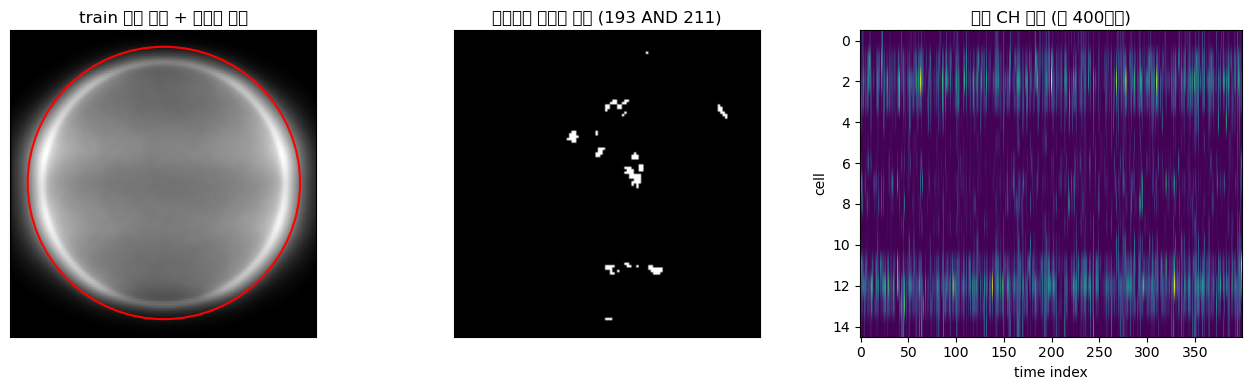

In [4]:
def detect_disk(image_array, sample_count=400):
    indexes = np.unique(np.linspace(0, len(image_array) - 1, sample_count).astype(int))
    mean_image = np.asarray(image_array[indexes], dtype=np.float64).mean(axis=(0, 1))
    # 배경은 어둡고 원반은 밝습니다. 단순 임계로 원반 픽셀을 잡습니다.
    mask = mean_image > mean_image.max() * 0.15
    ys, xs = np.nonzero(mask)
    center_y, center_x = float(ys.mean()), float(xs.mean())
    radius = float(np.sqrt(mask.sum() / np.pi))
    return center_y, center_x, radius, mean_image


DISK_Y, DISK_X, DISK_R, MEAN_IMAGE = detect_disk(train_image_array)
EFFECTIVE_R = DISK_R * DISK_MARGIN
print(f"원반 검출: center=({DISK_Y:.1f}, {DISK_X:.1f}) radius={DISK_R:.1f}px "
      f"(유효 {EFFECTIVE_R:.1f}px, 프레임의 {2*DISK_R/IMAGE_SIZE:.0%})")

grid_y, grid_x = np.mgrid[0:IMAGE_SIZE, 0:IMAGE_SIZE].astype(np.float64)
radius_map = np.sqrt((grid_y - DISK_Y) ** 2 + (grid_x - DISK_X) ** 2)
DISK_MASK = radius_map <= EFFECTIVE_R

# 원반 외접 사각형을 (위도, 경도) 격자로 분할
n_lat, n_lon = CH_GRID
lat_edge = np.clip(((grid_y - (DISK_Y - EFFECTIVE_R)) / (2 * EFFECTIVE_R) * n_lat), 0, n_lat - 1e-6)
lon_edge = np.clip(((grid_x - (DISK_X - EFFECTIVE_R)) / (2 * EFFECTIVE_R) * n_lon), 0, n_lon - 1e-6)
CELL_ID = (lat_edge.astype(np.int64) * n_lon + lon_edge.astype(np.int64))
CELL_ID_FLAT = CELL_ID[DISK_MASK]
N_CELLS = n_lat * n_lon
CELL_COUNTS = np.bincount(CELL_ID_FLAT, minlength=N_CELLS).astype(np.float32)
CELL_COUNTS = np.maximum(CELL_COUNTS, 1.0)
# 경도 중앙 열(자오선)과 적도 위도대의 셀 인덱스
CENTRAL_LON = n_lon // 2
EQUATOR_LAT = n_lat // 2
CENTRAL_CELL = EQUATOR_LAT * n_lon + CENTRAL_LON
print(f"격자 {n_lat}x{n_lon} = {N_CELLS} 셀, 원반 픽셀 {int(DISK_MASK.sum()):,}개, "
      f"중앙자오선 셀 index={CENTRAL_CELL}")


def compute_ch_grid(image_array, chunk=256):
    # 반환: (n_images, N_CELLS) 셀별 코로나홀 면적 비율
    result = np.zeros((len(image_array), N_CELLS), dtype=np.float32)
    onehot = np.zeros((len(CELL_ID_FLAT), N_CELLS), dtype=np.float32)
    onehot[np.arange(len(CELL_ID_FLAT)), CELL_ID_FLAT] = 1.0
    for start in range(0, len(image_array), chunk):
        block = np.asarray(image_array[start:start + chunk], dtype=np.float32)
        on_disk = block[:, :, DISK_MASK]                       # (n, 2, npix)
        median = np.median(on_disk, axis=2, keepdims=True)     # (n, 2, 1)
        dark = on_disk < (CH_THRESHOLD_RATIO * median)
        # 193 과 211 두 채널 모두에서 어두운 픽셀만 코로나홀로 인정
        coronal_hole = np.logical_and(dark[:, 0], dark[:, 1]).astype(np.float32)
        result[start:start + chunk] = (coronal_hole @ onehot) / CELL_COUNTS
    return result


def cached_ch_grid(split, image_array):
    path = CACHE_ROOT / f"ch_{split}_{n_lat}x{n_lon}_{CH_THRESHOLD_RATIO}_{IMAGE_SIZE}.npy"
    if path.exists():
        grid = np.load(path)
        if grid.shape == (len(image_array), N_CELLS):
            print(f"reusing CH cache: {path.name}")
            return grid
    grid = compute_ch_grid(image_array)
    np.save(path, grid)
    print(f"created CH cache: {path.name}  shape={grid.shape}")
    return grid


train_ch = cached_ch_grid("train", train_image_array)
val_ch = cached_ch_grid("validation", val_image_array)
test_ch = cached_ch_grid("test", test_image_array)

print(f"\nCH 면적 비율 — train 전체 평균 {train_ch.mean():.4f}, "
      f"중앙자오선 셀 평균 {train_ch[:, CENTRAL_CELL].mean():.4f}")

figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(MEAN_IMAGE, cmap="gray")
circle = plt.Circle((DISK_X, DISK_Y), EFFECTIVE_R, fill=False, color="red", linewidth=1.5)
axes[0].add_patch(circle)
axes[0].set_title("train 평균 영상 + 검출된 원반")
sample_image = np.asarray(train_image_array[0], dtype=np.float32)
sample_dark = sample_image < (CH_THRESHOLD_RATIO * np.median(sample_image[:, DISK_MASK], axis=1)[:, None, None])
axes[1].imshow(np.logical_and(sample_dark[0], sample_dark[1]) & DISK_MASK, cmap="gray")
axes[1].set_title("코로나홀 마스크 예시 (193 AND 211)")
axes[2].imshow(train_ch[:400].T, aspect="auto", cmap="viridis")
axes[2].set_title("셀별 CH 면적 (앞 400시점)")
axes[2].set_xlabel("time index"); axes[2].set_ylabel("cell")
for axis in axes[:2]:
    axis.set_xticks([]); axis.set_yticks([])
plt.tight_layout(); plt.show()

## 4. 정규화 통계 · 탄도 정렬 인덱스

**탄도 정렬**: horizon $h$ 의 타깃이 발원한 시각은 $T_0 + h - \tau$, $\tau = \mathrm{1AU}/v$.
가정 속도 $v \in \{350, 500, 700\}$ km/s 각각에 대해 윈도우 내 (실수) 인덱스를 계산해 둡니다.
윈도우를 벗어나면 양 끝으로 clamp 합니다 (고속풍 + 장기 horizon 은 아직 관측되지 않은 영역에서 발원).

In [5]:
def compute_image_stats(array, chunk=256):
    total = np.zeros(len(CHANNELS), np.float64)
    total_square = np.zeros(len(CHANNELS), np.float64)
    count = 0
    for start in range(0, len(array), chunk):
        block = np.asarray(array[start:start + chunk], dtype=np.float64) / 255.0
        total += block.sum(axis=(0, 2, 3))
        total_square += (block ** 2).sum(axis=(0, 2, 3))
        count += block.shape[0] * block.shape[2] * block.shape[3]
    mean = total / count
    return mean.astype(np.float32), np.sqrt(
        np.maximum(total_square / count - mean ** 2, 1e-12)).astype(np.float32)


IMAGE_MEAN, IMAGE_STD = compute_image_stats(train_image_array)
WIND_MEAN = float(train_wind.mean())
WIND_STD = float(train_wind.std() + 1e-6)
DIFF_STD = float(np.diff(train_wind, axis=1, prepend=train_wind[:, :1]).std() + 1e-6)
CH_MEAN = train_ch.mean(axis=0).astype(np.float32)
CH_STD = (train_ch.std(axis=0) + 1e-8).astype(np.float32)

train_residual = train_targets - train_wind[:, -1:]
RESIDUAL_MEAN = train_residual.mean(axis=0).astype(np.float32)
RESIDUAL_STD = (train_residual.std(axis=0) + 1e-6).astype(np.float32)
CLIP_LOW = float(train_targets.min() * 0.95)
CLIP_HIGH = float(train_targets.max() * 1.05)


def ballistic_indices():
    # (12, n_speeds) 윈도우 내 실수 인덱스. 인덱스 19 가 마지막 관측 시점 T0.
    table = np.zeros((12, len(TRANSIT_SPEEDS)), dtype=np.float32)
    for horizon_index in range(12):
        lead_hours = (horizon_index + 1) * 6.0
        for speed_index, speed in enumerate(TRANSIT_SPEEDS):
            transit_hours = AU_KM / speed / 3600.0
            table[horizon_index, speed_index] = np.clip(
                19.0 + (lead_hours - transit_hours) / 6.0, 0.0, 19.0)
    return table


BALLISTIC_INDEX = ballistic_indices()
N_SPEEDS = len(TRANSIT_SPEEDS)


def image_index_matrix(inputs, image_index):
    return np.asarray([
        [image_index[name] for name in row]
        for row in inputs[IMAGE_COLUMNS].itertuples(index=False, name=None)
    ], dtype=np.int32)


def compute_ballistic(ch_grid, indexes):
    # 중앙자오선 셀 시계열을 탄도 역산 인덱스에서 선형보간 -> (n, 12, n_speeds)
    central = ch_grid[indexes][:, :, CENTRAL_CELL]
    lower = np.floor(BALLISTIC_INDEX).astype(np.int64)
    upper = np.minimum(lower + 1, 19)
    weight = (BALLISTIC_INDEX - lower).astype(np.float32)
    return (central[:, lower] * (1.0 - weight) + central[:, upper] * weight).astype(np.float32)


# 탄도 피처 정규화 통계도 반드시 train split 에서만 산출합니다.
_train_ballistic = compute_ballistic(train_ch, image_index_matrix(train_inputs, train_image_index))
BALLISTIC_MEAN = float(_train_ballistic.mean())
BALLISTIC_STD = float(_train_ballistic.std() + 1e-8)

print("탄도 역산 — 가정 속도별 전달 시간:")
for speed in TRANSIT_SPEEDS:
    print(f"  v={speed:5.0f} km/s -> tau = {AU_KM / speed / 3600.0:5.1f} h "
          f"({AU_KM / speed / 86400.0:.2f} 일)")
print("\nhorizon별 근원 시점 인덱스 (19 = 마지막 관측):")
print(pd.DataFrame(BALLISTIC_INDEX, index=[f"{h}h" for h in HORIZONS],
                   columns=[f"v={int(v)}" for v in TRANSIT_SPEEDS]).round(2))
print(f"\nresidual std by horizon: {np.round(RESIDUAL_STD, 1)}")
print(f"clip range: [{CLIP_LOW:.1f}, {CLIP_HIGH:.1f}] km/s")

탄도 역산 — 가정 속도별 전달 시간:
  v=  350 km/s -> tau = 118.7 h (4.95 일)
  v=  500 km/s -> tau =  83.1 h (3.46 일)
  v=  700 km/s -> tau =  59.4 h (2.47 일)

horizon별 근원 시점 인덱스 (19 = 마지막 관측):
     v=350  v=500      v=700
6h    0.21   6.15  10.110000
12h   1.21   7.15  11.110000
18h   2.21   8.15  12.110000
24h   3.21   9.15  13.110000
30h   4.21  10.15  14.110000
36h   5.21  11.15  15.110000
42h   6.21  12.15  16.110001
48h   7.21  13.15  17.110001
54h   8.21  14.15  18.110001
60h   9.21  15.15  19.000000
66h  10.21  16.15  19.000000
72h  11.21  17.15  19.000000

residual std by horizon: [ 26.5  43.7  56.9  67.7  76.8  84.7  91.4  97.2 102.2 106.5 110.4 113.7]
clip range: [244.1, 865.2] km/s


## 5. Dataset

In [6]:
STAT_NAMES = ["last", "mean4", "mean", "std", "min", "max", "slope", "last_minus_mean4", "range"]
_TIME_CENTERED = np.arange(20, dtype=np.float32) - 9.5
_TIME_DENOMINATOR = float((_TIME_CENTERED ** 2).sum())


def build_wind_stats(wind):
    last = wind[:, -1]
    mean4 = wind[:, -4:].mean(axis=1)
    slope = (wind - wind.mean(axis=1, keepdims=True)) @ _TIME_CENTERED / _TIME_DENOMINATOR
    return np.stack([last, mean4, wind.mean(axis=1), wind.std(axis=1), wind.min(axis=1),
                     wind.max(axis=1), slope, last - mean4,
                     wind.max(axis=1) - wind.min(axis=1)], axis=1).astype(np.float32)


train_stats_raw = build_wind_stats(train_wind)
STATS_MEAN = train_stats_raw.mean(axis=0).astype(np.float32)
STATS_STD = (train_stats_raw.std(axis=0) + 1e-6).astype(np.float32)
NUM_STATS = len(STAT_NAMES)


class SolarWindDataset(Dataset):
    def __init__(self, image_array, image_index, inputs, wind, wind_valid,
                 ch_grid, targets=None, training=False):
        self.training = training
        self.image_array = image_array
        self.image_indexes = image_index_matrix(inputs, image_index)
        self.sample_ids = inputs.sample_id.to_numpy()
        self.last_wind = np.ascontiguousarray(wind[:, -1]).astype(np.float32)
        self.wind_seq = np.stack([
            (wind - WIND_MEAN) / WIND_STD,
            np.diff(wind, axis=1, prepend=wind[:, :1]) / DIFF_STD,
            wind_valid,
        ], axis=2).astype(np.float32)
        self.wind_stats = ((build_wind_stats(wind) - STATS_MEAN) / STATS_STD).astype(np.float32)

        # (n_samples, 20, N_CELLS) 시퀀스로 미리 펼쳐 둡니다.
        self.ch_seq = ((ch_grid[self.image_indexes] - CH_MEAN) / CH_STD).astype(np.float32)
        # 탄도 정렬 피처. 정규화는 train 통계(BALLISTIC_MEAN/STD)로 고정합니다.
        self.ballistic = ((compute_ballistic(ch_grid, self.image_indexes) - BALLISTIC_MEAN)
                          / BALLISTIC_STD).astype(np.float32)           # (n, 12, n_speeds)

        self.targets = targets.astype(np.float32) if targets is not None else None
        self.image_mean = IMAGE_MEAN.reshape(1, len(CHANNELS), 1, 1)
        self.image_std = IMAGE_STD.reshape(1, len(CHANNELS), 1, 1)

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, item):
        if USE_CNN:
            images = np.asarray(
                self.image_array[self.image_indexes[item]], dtype=np.float32) / 255.0
            images = ((images - self.image_mean) / self.image_std).astype(np.float32)
        else:
            images = np.zeros((1, 1, 1, 1), dtype=np.float32)

        ch_seq = self.ch_seq[item]
        ballistic = self.ballistic[item]
        if self.training and AUGMENT and AUG_CH_NOISE > 0:
            # CH 피처에도 약한 곱셈 노이즈를 줘 브랜치 과적합을 억제합니다.
            ch_seq = ch_seq * (1.0 + np.random.normal(0, AUG_CH_NOISE, ch_seq.shape)
                               ).astype(np.float32)
            ballistic = ballistic * (1.0 + np.random.normal(
                0, AUG_CH_NOISE, ballistic.shape)).astype(np.float32)

        result = {
            "images": torch.from_numpy(np.ascontiguousarray(images)),
            "wind_seq": torch.from_numpy(self.wind_seq[item]),
            "wind_stats": torch.from_numpy(self.wind_stats[item]),
            "ch_seq": torch.from_numpy(np.ascontiguousarray(ch_seq)),
            "ballistic": torch.from_numpy(np.ascontiguousarray(ballistic)),
            "last_wind": torch.tensor(self.last_wind[item]),
            "sample_id": self.sample_ids[item],
        }
        if self.targets is not None:
            result["target"] = torch.from_numpy(self.targets[item])
        return result


def seed_worker(worker_id):
    worker_seed = (SEED + worker_id) % (2 ** 32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def make_loader(dataset, shuffle):
    options = dict(dataset=dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
                   num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
                   worker_init_fn=seed_worker,
                   generator=torch.Generator().manual_seed(SEED))
    if NUM_WORKERS > 0:
        options.update(persistent_workers=True, prefetch_factor=2)
    return DataLoader(**options)


train_dataset = SolarWindDataset(train_image_array, train_image_index, train_inputs,
                                 train_wind, train_wind_valid, train_ch,
                                 train_targets, training=True)
val_dataset = SolarWindDataset(val_image_array, val_image_index, val_inputs,
                               val_wind, val_wind_valid, val_ch, val_targets)
train_loader = make_loader(train_dataset, shuffle=True)
val_loader = make_loader(val_dataset, shuffle=False)

batch = next(iter(train_loader))
assert batch["ch_seq"].shape[1:] == (20, N_CELLS)
assert batch["ballistic"].shape[1:] == (12, N_SPEEDS)
print({k: tuple(v.shape) for k, v in batch.items() if torch.is_tensor(v)})

{'images': (64, 1, 1, 1, 1), 'wind_seq': (64, 20, 3), 'wind_stats': (64, 9), 'ch_seq': (64, 20, 15), 'ballistic': (64, 12, 3), 'last_wind': (64,), 'target': (64, 12)}


## 6. 모델

- **CH 브랜치** — 셀별 면적 시퀀스 `(20, N_CELLS)` → GRU. 저차원이라 과적합에 강함
- **Wind 브랜치** — P1 과 동일 (GRU + 통계)
- **CNN 브랜치** — `USE_CNN=True` 일 때만. 기본은 꺼짐
- **head** — horizon 12개에 **가중치를 공유**하고, horizon embedding 과
  해당 horizon 의 탄도 피처만 다르게 넣습니다. 파라미터가 12배 줄어 정규화 효과가 큽니다

In [7]:
class Inception3D(nn.Module):
    def __init__(self, in_channels, branch_channels=32):
        super().__init__()
        self.branch_1 = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, 1), nn.ReLU(inplace=True))
        self.branch_3 = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, 1), nn.ReLU(inplace=True),
            nn.Conv3d(branch_channels, branch_channels, (1, 3, 3), padding=(0, 1, 1)),
            nn.ReLU(inplace=True))
        self.branch_5 = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, 1), nn.ReLU(inplace=True),
            nn.Conv3d(branch_channels, branch_channels, (1, 5, 5), padding=(0, 2, 2)),
            nn.ReLU(inplace=True))
        self.branch_pool = nn.Sequential(
            nn.MaxPool3d((1, 3, 3), stride=1, padding=(0, 1, 1)),
            nn.Conv3d(in_channels, branch_channels, 1), nn.ReLU(inplace=True))

    def forward(self, x):
        return torch.cat([self.branch_1(x), self.branch_3(x),
                          self.branch_5(x), self.branch_pool(x)], dim=1)


class SolarWindP3(nn.Module):
    def __init__(self):
        super().__init__()
        shared_dim = 0

        self.wind_gru = nn.GRU(3, 96, num_layers=2, batch_first=True)
        self.stats_encoder = nn.Sequential(
            nn.Linear(NUM_STATS, 128), nn.SELU(inplace=True),
            nn.Linear(128, 64), nn.SELU(inplace=True))
        shared_dim += 96 + 64

        if USE_CH:
            self.ch_gru = nn.GRU(N_CELLS, 64, num_layers=2, batch_first=True)
            self.ch_dropout = nn.Dropout(CH_DROPOUT)
            shared_dim += 64

        if USE_CNN:
            self.stem = nn.Sequential(
                nn.Conv3d(len(CHANNELS), 32, (1, 5, 5), padding=(0, 2, 2)),
                nn.BatchNorm3d(32), nn.ReLU(inplace=True),
                nn.MaxPool3d((1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1)),
                nn.Conv3d(32, 64, (1, 3, 3), padding=(0, 1, 1)),
                nn.BatchNorm3d(64), nn.ReLU(inplace=True),
                nn.MaxPool3d((1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1)))
            blocks, in_channels = [], 64
            for _ in range(3):
                blocks.extend([Inception3D(in_channels, 32),
                               nn.MaxPool3d((1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1))])
                in_channels = 128
            self.image_encoder = nn.Sequential(*blocks)
            self.image_lstm = nn.LSTM(128 * 1 * 4, 128, batch_first=True)
            self.image_dropout = nn.Dropout(DROPOUT)
            shared_dim += 128

        self.horizon_embedding = nn.Parameter(torch.randn(12, HORIZON_EMBED) * 0.1)
        head_input = shared_dim + HORIZON_EMBED + (N_SPEEDS if USE_BALLISTIC else 0)
        # head 는 12 horizon 에 동일 가중치로 적용됩니다 (nn.Linear 는 마지막 축에만 작용).
        self.head = nn.Sequential(
            nn.Linear(head_input, 192), nn.ReLU(inplace=True), nn.Dropout(DROPOUT),
            nn.Linear(192, 96), nn.ReLU(inplace=True), nn.Dropout(DROPOUT),
            nn.Linear(96, 1))

        self.register_buffer("residual_mean", torch.as_tensor(RESIDUAL_MEAN))
        self.register_buffer("residual_std", torch.as_tensor(RESIDUAL_STD))
        print(f"shared_dim={shared_dim}  head_input={head_input}")

    def forward(self, images, wind_seq, wind_stats, ch_seq, ballistic):
        _, wind_hidden = self.wind_gru(wind_seq)
        parts = [F.relu(wind_hidden[-1]), self.stats_encoder(wind_stats)]

        if USE_CH:
            _, ch_hidden = self.ch_gru(ch_seq)
            parts.append(self.ch_dropout(F.relu(ch_hidden[-1])))

        if USE_CNN:
            features = images.permute(0, 2, 1, 3, 4).contiguous()
            features = self.image_encoder(self.stem(features))
            features = F.adaptive_avg_pool3d(features, (features.shape[2], 1, 4))
            features = features.permute(0, 2, 1, 3, 4).flatten(2)
            _, (hidden, _) = self.image_lstm(features)
            parts.append(self.image_dropout(F.relu(hidden[-1])))

        shared = torch.cat(parts, dim=1)                                   # (B, D)
        batch_size = shared.shape[0]
        expanded = shared.unsqueeze(1).expand(batch_size, 12, shared.shape[1])
        embedding = self.horizon_embedding.unsqueeze(0).expand(batch_size, 12, HORIZON_EMBED)
        head_parts = [expanded, embedding]
        if USE_BALLISTIC:
            head_parts.append(ballistic)
        z = self.head(torch.cat(head_parts, dim=2)).squeeze(-1)            # (B, 12)
        return z * self.residual_std + self.residual_mean


def build_model():
    return SolarWindP3().to(DEVICE)


model = build_model()
print("trainable parameters:",
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

shared_dim=224  head_input=235
trainable parameters: 199,041


## 7. 지표 · 손실

In [8]:
def official_rmse(y_true, y_pred):
    per_horizon = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))
    return float(per_horizon.mean()), per_horizon


def pooled_rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def metrics_by_horizon(y_true, y_pred, persistence=None):
    rows = []
    for index in range(12):
        actual, predicted = y_true[:, index], y_pred[:, index]
        error = predicted - actual
        denominator = np.std(actual) * np.std(predicted)
        row = {"horizon_h": int(HORIZONS[index]),
               "rmse": float(np.sqrt(np.mean(error ** 2))),
               "mae": float(np.mean(np.abs(error))),
               "corr": float(np.corrcoef(actual, predicted)[0, 1]) if denominator > 0 else np.nan}
        if persistence is not None:
            row["persistence_rmse"] = float(np.sqrt(np.mean((persistence[:, index] - actual) ** 2)))
            row["gain"] = row["persistence_rmse"] - row["rmse"]
        rows.append(row)
    return pd.DataFrame(rows)


def metric_loss(prediction, target):
    error = (prediction - target) / LOSS_SCALE
    if LOSS_MODE == "mse":
        return (error ** 2).mean()
    return torch.sqrt((error ** 2).mean(dim=0) + LOSS_EPSILON).mean()


def augment_batch(images):
    # GPU 에서 수행합니다. numpy 증강은 CPU 병목으로 epoch 시간이 4배 늘었습니다.
    if AUG_SHIFT_PIXELS > 0:
        shift_y = int(torch.randint(-AUG_SHIFT_PIXELS, AUG_SHIFT_PIXELS + 1, (1,)).item())
        shift_x = int(torch.randint(-AUG_SHIFT_PIXELS, AUG_SHIFT_PIXELS + 1, (1,)).item())
        images = torch.roll(images, shifts=(shift_y, shift_x), dims=(3, 4))
    count = images.shape[0]
    scale = 1.0 + (torch.rand(count, 1, 1, 1, 1, device=images.device) * 2 - 1) * AUG_BRIGHTNESS
    offset = torch.randn(count, 1, 1, 1, 1, device=images.device) * AUG_BRIGHTNESS
    images = images * scale + offset
    if AUG_NOISE_STD > 0:
        images = images + torch.randn_like(images) * AUG_NOISE_STD
    if AUG_ERASE_PROB > 0:
        size = max(4, IMAGE_SIZE // 8)
        selected = torch.rand(count, device=images.device) < AUG_ERASE_PROB
        if bool(selected.any()):
            top = int(torch.randint(0, IMAGE_SIZE - size, (1,)).item())
            left = int(torch.randint(0, IMAGE_SIZE - size, (1,)).item())
            images[selected, :, :, top:top + size, left:left + size] = 0.0
    return images


val_persistence = np.repeat(val_wind[:, -1:], 12, axis=1).astype(np.float64)
persistence_score, persistence_per_horizon = official_rmse(val_targets, val_persistence)
print(f"[기준선] persistence 공식 RMSE = {persistence_score:.3f} km/s")
print("horizon별:", np.round(persistence_per_horizon, 1))

[기준선] persistence 공식 RMSE = 84.105 km/s
horizon별: [ 30.1  49.6  63.   73.3  82.   89.2  94.7  99.1 102.7 106.  108.7 110.9]


## 8. 학습

shared_dim=224  head_input=235
epoch=001 train= 66.750 val= 66.224 lr=3.00e-04    2.3s  <- best
epoch=002 train= 61.174 val= 64.533 lr=3.00e-04    1.6s  <- best
epoch=003 train= 59.117 val= 64.785 lr=3.00e-04    1.6s
epoch=004 train= 57.795 val= 65.953 lr=3.00e-04    1.7s
epoch=005 train= 56.398 val= 64.268 lr=3.00e-04    1.6s  <- best
epoch=006 train= 55.471 val= 65.825 lr=3.00e-04    1.6s
epoch=007 train= 54.791 val= 66.997 lr=3.00e-04    1.6s
epoch=008 train= 53.669 val= 65.178 lr=3.00e-04    1.6s
epoch=009 train= 52.930 val= 67.289 lr=1.50e-04    1.7s
epoch=010 train= 51.661 val= 66.290 lr=1.50e-04    1.7s
epoch=011 train= 51.258 val= 67.030 lr=1.50e-04    1.7s
epoch=012 train= 50.719 val= 67.270 lr=1.50e-04    1.7s
epoch=013 train= 50.492 val= 66.968 lr=7.50e-05    1.7s
epoch=014 train= 49.883 val= 68.300 lr=7.50e-05    1.6s
epoch=015 train= 49.700 val= 68.010 lr=7.50e-05    1.6s
early stopping


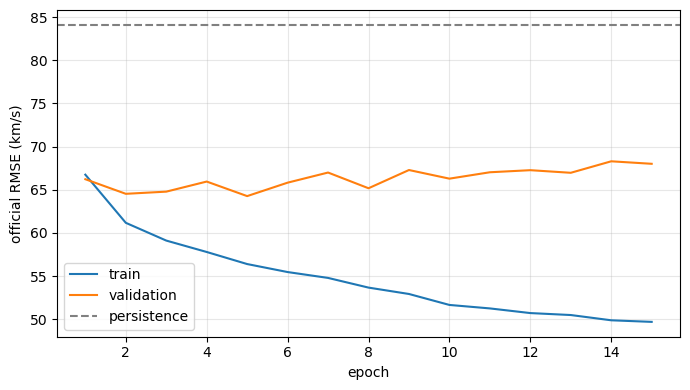

best epoch 5  val official RMSE 64.268


In [9]:
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = build_model()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=SCHEDULER_PATIENCE, min_lr=1e-6)
scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)

checkpoint_path = OUTPUT_DIR / "best_model.pth"
if checkpoint_path.exists():
    checkpoint_path.unlink()
best_val_score = float("inf")
epochs_without_improvement = 0
history = []

CONFIG = {"image_size": IMAGE_SIZE, "channels": list(CHANNELS), "use_cnn": USE_CNN,
          "use_ch": USE_CH, "use_ballistic": USE_BALLISTIC, "ch_grid": list(CH_GRID),
          "ch_threshold_ratio": CH_THRESHOLD_RATIO, "disk": [DISK_Y, DISK_X, DISK_R],
          "transit_speeds": list(TRANSIT_SPEEDS), "seed": SEED,
          "image_mean": IMAGE_MEAN.tolist(), "image_std": IMAGE_STD.tolist(),
          "wind_mean": WIND_MEAN, "wind_std": WIND_STD, "diff_std": DIFF_STD,
          "ch_mean": CH_MEAN.tolist(), "ch_std": CH_STD.tolist(),
          "stats_mean": STATS_MEAN.tolist(), "stats_std": STATS_STD.tolist(),
          "residual_mean": RESIDUAL_MEAN.tolist(), "residual_std": RESIDUAL_STD.tolist(),
          "clip_low": CLIP_LOW, "clip_high": CLIP_HIGH,
          "initialization": "random_from_scratch"}


def run_epoch(loader, training):
    model.train(training)
    squared_error_sum = np.zeros(12, dtype=np.float64)
    sample_count = 0
    for batch in loader:
        images = batch["images"].to(DEVICE, non_blocking=PIN_MEMORY)
        wind_seq = batch["wind_seq"].to(DEVICE, non_blocking=PIN_MEMORY)
        wind_stats = batch["wind_stats"].to(DEVICE, non_blocking=PIN_MEMORY)
        ch_seq = batch["ch_seq"].to(DEVICE, non_blocking=PIN_MEMORY)
        ballistic = batch["ballistic"].to(DEVICE, non_blocking=PIN_MEMORY)
        last_wind = batch["last_wind"].to(DEVICE, non_blocking=PIN_MEMORY)
        target = batch["target"].to(DEVICE, non_blocking=PIN_MEMORY)

        if training and USE_CNN and AUGMENT:
            images = augment_batch(images)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
                residual = model(images, wind_seq, wind_stats, ch_seq, ballistic)
            prediction = residual.float() + last_wind.unsqueeze(1)
            loss = metric_loss(prediction, target)
            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()

        error = (prediction.detach() - target).double()
        squared_error_sum += torch.sum(error ** 2, dim=0).cpu().numpy()
        sample_count += error.shape[0]
    per_horizon = np.sqrt(squared_error_sum / sample_count)
    return float(per_horizon.mean()), per_horizon


for epoch in range(1, EPOCHS + 1):
    started = time.perf_counter()
    train_score, _ = run_epoch(train_loader, training=True)
    with torch.no_grad():
        val_score, _ = run_epoch(val_loader, training=False)
    scheduler.step(val_score)
    learning_rate = optimizer.param_groups[0]["lr"]
    elapsed = time.perf_counter() - started
    history.append({"epoch": epoch, "train_rmse": train_score, "val_rmse": val_score,
                    "learning_rate": learning_rate, "seconds": elapsed})
    marker = ""
    if val_score < best_val_score:
        best_val_score = val_score
        epochs_without_improvement = 0
        torch.save({"model_state_dict": model.state_dict(), "epoch": epoch,
                    "val_official_rmse": val_score, **CONFIG}, checkpoint_path)
        marker = "  <- best"
    else:
        epochs_without_improvement += 1
    print(f"epoch={epoch:03d} train={train_score:7.3f} val={val_score:7.3f} "
          f"lr={learning_rate:.2e} {elapsed:6.1f}s{marker}", flush=True)
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print("early stopping")
        break

history_frame = pd.DataFrame(history)
history_frame.to_csv(OUTPUT_DIR / "history.csv", index=False)
figure, axis = plt.subplots(figsize=(7, 4))
axis.plot(history_frame.epoch, history_frame.train_rmse, label="train")
axis.plot(history_frame.epoch, history_frame.val_rmse, label="validation")
axis.axhline(persistence_score, color="gray", linestyle="--", label="persistence")
axis.set_xlabel("epoch"); axis.set_ylabel("official RMSE (km/s)")
axis.grid(alpha=0.3); axis.legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "learning_curve.png", dpi=140); plt.show()

checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"best epoch {checkpoint['epoch']}  val official RMSE {checkpoint['val_official_rmse']:.3f}")

## 9. Validation 평가

공식 RMSE (mean of horizon RMSE) :   64.268 km/s
pooled RMSE (전체 원소)          :   65.948 km/s
persistence 공식 RMSE            :   84.105 km/s
persistence 대비 개선             :   19.837 km/s  (23.6%)

[참고] P1 = 68.408 / P2a = 65.663


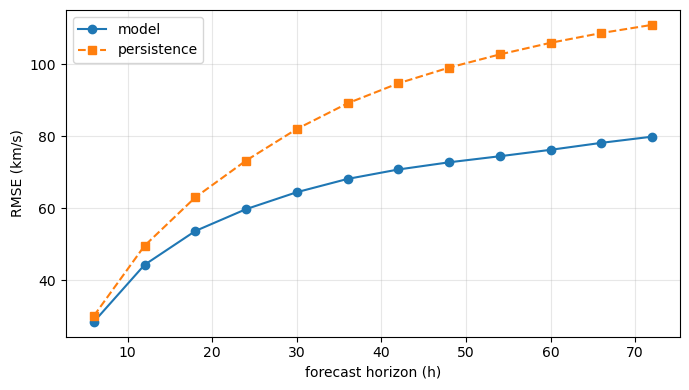

,horizon_h,rmse,mae,corr,persistence_rmse,gain
0,6,28.474799,18.874778,0.952567,30.133799,1.659001
1,12,44.316472,30.023591,0.880299,49.612603,5.296131
2,18,53.700601,37.547470,0.819266,63.040371,9.339771
3,24,59.770400,42.631033,0.771869,73.255360,13.484960
4,30,64.474934,46.217524,0.728887,82.029491,17.554557
5,36,68.160692,49.182311,0.692784,89.150125,20.989433
6,42,70.777555,51.505407,0.664941,94.699058,23.921503
7,48,72.773468,53.449192,0.642978,99.061863,26.288395
8,54,74.458111,55.199693,0.623338,102.730158,28.272047
9,60,76.239777,57.074359,0.602188,105.953524,29.713747


In [10]:
@torch.no_grad()
def predict(loader):
    model.eval()
    predictions, sample_ids = [], []
    for batch in loader:
        images = batch["images"].to(DEVICE, non_blocking=PIN_MEMORY)
        wind_seq = batch["wind_seq"].to(DEVICE, non_blocking=PIN_MEMORY)
        wind_stats = batch["wind_stats"].to(DEVICE, non_blocking=PIN_MEMORY)
        ch_seq = batch["ch_seq"].to(DEVICE, non_blocking=PIN_MEMORY)
        ballistic = batch["ballistic"].to(DEVICE, non_blocking=PIN_MEMORY)
        last_wind = batch["last_wind"].to(DEVICE, non_blocking=PIN_MEMORY)
        with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
            residual = model(images, wind_seq, wind_stats, ch_seq, ballistic)
        prediction = (residual.float() + last_wind.unsqueeze(1)).clamp(CLIP_LOW, CLIP_HIGH)
        predictions.append(prediction.cpu().numpy())
        sample_ids.extend(batch["sample_id"])
    return np.concatenate(predictions).astype(np.float64), sample_ids


validation_prediction, validation_ids = predict(val_loader)
assert validation_ids == val_inputs.sample_id.tolist()
model_score, _ = official_rmse(val_targets, validation_prediction)
validation_metrics = metrics_by_horizon(val_targets, validation_prediction, val_persistence)
validation_metrics.to_csv(OUTPUT_DIR / "validation_metrics.csv", index=False)

print(f"공식 RMSE (mean of horizon RMSE) : {model_score:8.3f} km/s")
print(f"pooled RMSE (전체 원소)          : {pooled_rmse(val_targets, validation_prediction):8.3f} km/s")
print(f"persistence 공식 RMSE            : {persistence_score:8.3f} km/s")
print(f"persistence 대비 개선             : {persistence_score - model_score:8.3f} km/s"
      f"  ({(persistence_score - model_score) / persistence_score:.1%})")
print("\n[참고] P1 = 68.408 / P2a = 65.663")
if model_score >= persistence_score:
    print("\n>>> 경고: persistence 미달. 제출하지 마세요.")

figure, axis = plt.subplots(figsize=(7, 4))
axis.plot(validation_metrics.horizon_h, validation_metrics.rmse, marker="o", label="model")
axis.plot(validation_metrics.horizon_h, validation_metrics.persistence_rmse,
          marker="s", linestyle="--", label="persistence")
axis.set_xlabel("forecast horizon (h)"); axis.set_ylabel("RMSE (km/s)")
axis.grid(alpha=0.3); axis.legend()
plt.tight_layout(); plt.show()
validation_metrics

## 10. Test 추론 · 제출 파일 생성

In [11]:
del train_loader, val_loader, train_dataset, val_dataset
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

test_dataset = SolarWindDataset(test_image_array, test_image_index, test_inputs,
                                test_wind, test_wind_valid, test_ch, targets=None)
test_loader = make_loader(test_dataset, shuffle=False)
test_prediction, predicted_ids = predict(test_loader)

assert predicted_ids == test_inputs.sample_id.tolist()
assert test_prediction.shape == (len(test_inputs), 12)
assert np.isfinite(test_prediction).all()

submission = pd.DataFrame(test_prediction, columns=TARGET_COLUMNS)
submission.insert(0, "sample_id", predicted_ids)
submission.to_csv(SUBMISSION_DIR / "submission.csv", index=False)
shutil.copyfile(checkpoint_path, SUBMISSION_DIR / "model.pth")

# 규정: "code.ipynb 에서 model.pth 를 불러와 추론이 가능해야 함" 을 문자 그대로 충족
saved = torch.load(SUBMISSION_DIR / "model.pth", map_location=DEVICE, weights_only=True)
model.load_state_dict(saved["model_state_dict"])
print("reloaded from submission/model.pth")

print("saved:", (SUBMISSION_DIR / "submission.csv").resolve(), submission.shape)
print(submission[TARGET_COLUMNS].describe().loc[["mean", "std", "min", "max"]].round(1))
del test_dataset, test_loader
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
submission.head()

reloaded from submission/model.pth
saved: /home/jovyan/submission/submission.csv (3868, 13)
      target_00  target_01  target_02  target_03  target_04  target_05  \
mean      408.3      409.5      411.0      412.1      413.4      414.6   
std        84.7       81.0       76.0       72.6       69.8       67.4   
min       269.0      277.1      288.8      293.0      299.9      304.9   
max       732.4      722.1      706.1      690.2      683.6      700.6   

      target_06  target_07  target_08  target_09  target_10  target_11  
mean      415.7      416.5      417.5      418.0      418.5      418.9  
std        66.1       65.2       64.8       64.8       64.7       64.8  
min       311.2      316.3      320.7      322.0      325.5      326.6  
max       709.0      713.2      721.1      732.9      733.6      738.2  


,sample_id,target_00,target_01,target_02,target_03,target_04,target_05,target_06,target_07,target_08,target_09,target_10,target_11
0,sample_07393cebc8e6882a,634.697083,628.068787,617.673950,605.938660,591.628906,574.167236,559.967957,541.485779,521.261414,507.215485,495.552338,488.516174
1,sample_640b9e2639db9b4f,383.065063,381.091156,379.791840,378.524200,378.048401,377.606354,377.159332,376.889313,376.484650,375.917908,376.086884,375.675537
2,sample_cd1159b14b325e4b,422.084930,413.139252,402.090302,394.029755,385.230072,376.089935,368.792664,362.180756,357.054932,353.226501,348.348267,344.193787
3,sample_cdb23a4bf60ec4df,380.463684,377.948456,374.211365,371.027039,367.395172,362.355377,358.652679,357.024872,354.374481,354.686493,354.414520,348.074768
4,sample_3713237d245e38bb,419.993286,431.783844,448.573273,455.900391,470.150940,472.575470,478.603333,487.631836,493.079498,493.219666,498.042603,499.791504


## 11. 제출 전 체크리스트

> ⚠️ `code.ipynb` 는 **수동 복사**입니다. 저장(Ctrl+S) 후 `submission/code.ipynb` 로 복사하세요.

In [12]:
EXPECTED_TEST_ROWS = 3868

print("=== 제출 점검 ===")
ok = True
for name in ["code.ipynb", "model.pth", "submission.csv"]:
    path = SUBMISSION_DIR / name
    if path.exists():
        print(f"  [O] {name:16s} {path.stat().st_size / 1024 ** 2:8.2f} MiB")
    else:
        print(f"  [X] {name:16s} 없음")
        ok = False

check = pd.read_csv(SUBMISSION_DIR / "submission.csv")
print(f"\n  행 수      : {len(check):,} (기대 {EXPECTED_TEST_ROWS:,})",
      "OK" if len(check) == EXPECTED_TEST_ROWS else "<-- 불일치")
print(f"  컬럼       : {check.columns.tolist() == ['sample_id'] + TARGET_COLUMNS}")
print(f"  결측       : {int(check[TARGET_COLUMNS].isna().sum().sum())}")
print(f"  sample_id  : 유일={check.sample_id.is_unique}, "
      f"test_ids 일치={sorted(check.sample_id) == sorted(test_ids.sample_id)}")
print(f"  값 범위    : [{check[TARGET_COLUMNS].to_numpy().min():.1f}, "
      f"{check[TARGET_COLUMNS].to_numpy().max():.1f}] km/s")

extra = [p.name for p in SUBMISSION_DIR.iterdir()
         if p.name not in {"code.ipynb", "model.pth", "submission.csv"}]
if extra:
    print(f"\n  주의: 불필요한 파일 -> {extra}")

=== 제출 점검 ===
  [O] code.ipynb           0.86 MiB
  [O] model.pth            0.77 MiB
  [O] submission.csv       0.88 MiB

  행 수      : 3,868 (기대 3,868) OK
  컬럼       : True
  결측       : 0
  sample_id  : 유일=True, test_ids 일치=True
  값 범위    : [269.0, 738.2] km/s

  주의: 불필요한 파일 -> ['.ipynb_checkpoints']
